In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import joblib

In [2]:
medicare_fraud1 = pd.read_csv(
    "../data/raw/TRAIN2.csv",
    encoding='utf-8-sig'
)

medicare_fraud1.columns = medicare_fraud1.columns.str.replace('ï»¿', '')

In [3]:
medicare_fraud1.head()

,Provider,PotentialFraud,InscClaimAmtReimbursed,DeductibleAmtPaid,AdmitForDays,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,...,ClmCount_Provider_BeneID_AttendingPhysician_ClmProcedureCode_1,ClmCount_Provider_BeneID_AttendingPhysician_ClmDiagnosisCode_1,ClmCount_Provider_BeneID_OperatingPhysician,ClmCount_Provider_BeneID_ClmProcedureCode_1,ClmCount_Provider_BeneID_ClmDiagnosisCode_1,ClmCount_Provider_BeneID_ClmDiagnosisCode_1_ClmProcedureCode_1,Gender_2,Race_2,Race_3,Race_5
0,PRV51001,0,104640,5340,30,300,300,15,19,17,...,2,24,5,2,24,2,16,4,0,0
1,PRV51003,1,605670,66286,382,1560,1567,56,80,64,...,39,132,45,39,132,39,78,24,0,1
2,PRV51004,0,52170,310,0,1768,1782,64,88,50,...,0,143,27,0,143,0,103,24,5,0
3,PRV51005,1,280910,3700,0,13872,13910,426,680,507,...,0,1151,264,0,1171,0,654,262,10,0
4,PRV51007,0,33710,3264,19,852,852,26,40,22,...,1,72,12,1,72,1,38,14,0,0


In [4]:
medicare_fraud1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Columns: 158 entries, Provider to Race_5
dtypes: float64(88), int64(69), str(1)
memory usage: 6.5 MB


In [5]:
y = medicare_fraud1["PotentialFraud"]

x = medicare_fraud1.drop(
    columns=["Provider", "PotentialFraud"]
)

In [6]:
print(x.shape)
print(y.shape)

(5410, 156)
(5410,)


In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4328, 156)
(1082, 156)
(4328,)
(1082,)


In [9]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

In [10]:
svc = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

In [11]:
svc.fit(x_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
y_pred = svc.predict(x_test_scaled)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(accuracy)

Accuracy Score:
0.88909426987061


In [14]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       981
           1       0.45      0.83      0.58       101

    accuracy                           0.89      1082
   macro avg       0.72      0.86      0.76      1082
weighted avg       0.93      0.89      0.90      1082



In [15]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[878 103]
 [ 17  84]]


In [16]:
y_prob = svc.predict_proba(x_test_scaled)[:, 1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:")
print(roc_score)

ROC-AUC Score:
0.9373845641444878


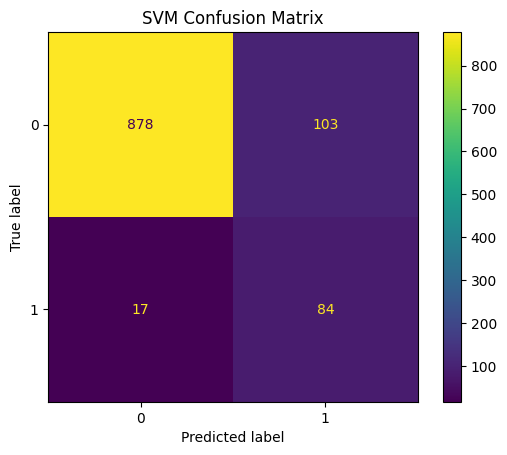

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("SVM Confusion Matrix")

plt.show()

In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

In [19]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
rf_pred = rf.predict(x_test)

rf_prob = rf.predict_proba(x_test)[:,1]

In [21]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.9426987060998152


In [22]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.77      0.55      0.64       101

    accuracy                           0.94      1082
   macro avg       0.86      0.77      0.81      1082
weighted avg       0.94      0.94      0.94      1082



In [23]:
print("Random Forest ROC-AUC:")
print(roc_auc_score(y_test, rf_prob))

Random Forest ROC-AUC:
0.9494151249987384


In [24]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
})

In [25]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [26]:
feature_importance.head(20)

,Feature,Importance
22,PerProviderAvg_InscClaimAmtReimbursed,0.061232
0,InscClaimAmtReimbursed,0.048696
53,PerAttendingPhysicianAvg_InscClaimAmtReimbursed,0.040375
68,PerClmAdmitDiagnosisCodeAvg_DeductibleAmtPaid,0.039508
46,PerOperatingPhysicianAvg_InscClaimAmtReimbursed,0.039244
141,ClmCount_Provider_ClmDiagnosisCode_8,0.028782
142,ClmCount_Provider_ClmDiagnosisCode_9,0.026828
67,PerClmAdmitDiagnosisCodeAvg_InscClaimAmtReimbu...,0.026615
96,PerClmDiagnosisCode_1Avg_DeductibleAmtPaid,0.025539
23,PerProviderAvg_DeductibleAmtPaid,0.023711


In [27]:
feature_importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

In [28]:
top_features = feature_importance.head(15)

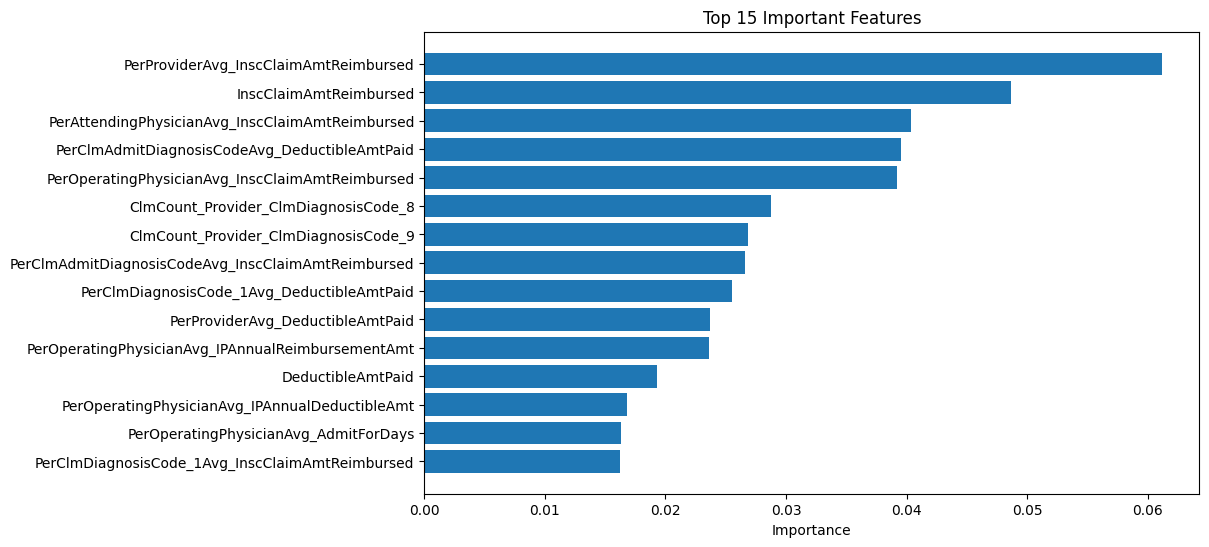

In [29]:
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

In [30]:
joblib.dump(
    svc,
    "../models/svm_fraud_model.pkl"
)

['../models/svm_fraud_model.pkl']

In [31]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [32]:
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [33]:
predictions_df.head()

,Actual,Predicted
1266,0,0
1394,0,0
1862,0,0
1736,0,0
4138,0,0


In [34]:
predictions_df.to_csv(
    "../outputs/predictions.csv",
    index=False
)

In [35]:
test_fraud = pd.read_csv(
    "../data/raw/TEST.csv",
    encoding='utf-8-sig'
)

test_fraud.columns = test_fraud.columns.str.replace('ï»¿', '')

In [36]:
test_fraud.head()

,Provider,InscClaimAmtReimbursed,DeductibleAmtPaid,AdmitForDays,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,...,ClmCount_Provider_BeneID_AttendingPhysician_ClmProcedureCode_1,ClmCount_Provider_BeneID_AttendingPhysician_ClmDiagnosisCode_1,ClmCount_Provider_BeneID_OperatingPhysician,ClmCount_Provider_BeneID_ClmProcedureCode_1,ClmCount_Provider_BeneID_ClmDiagnosisCode_1,ClmCount_Provider_BeneID_ClmDiagnosisCode_1_ClmProcedureCode_1,Gender_2,Race_2,Race_3,Race_5
0,PRV51002,53790,380,0,2424,2460,79,108,72,25,...,0,202,30,0,204,0,134,30,2,4
1,PRV51006,30720,0,0,1224,1224,35,69,50,15,...,0,99,26,0,99,0,59,26,0,0
2,PRV51009,27230,1238,8,468,468,8,17,19,1,...,2,40,24,2,41,2,23,6,0,0
3,PRV51010,64580,5340,29,444,444,21,23,19,7,...,3,38,9,3,38,3,15,1,0,0
4,PRV51018,61620,670,0,2232,2276,73,109,93,25,...,0,188,30,0,188,0,124,45,0,0


In [37]:
Provider = test_fraud["Provider"]

In [38]:
test_fraud = test_fraud.drop(
    columns=["Provider"]
)

In [39]:
print(test_fraud.shape)

(1353, 156)


In [40]:
print(
    x.columns.equals(test_fraud.columns)
)

True


In [41]:
test_scaled = scaler.transform(test_fraud)

In [42]:
submission_predict = svc.predict(test_scaled)

In [43]:
submission = pd.DataFrame({
    "Provider": Provider,
    "PotentialFraud": submission_predict
})

In [44]:
submission["PotentialFraud"] = submission[
    "PotentialFraud"
].map({
    0: "No",
    1: "Yes"
})

In [45]:
submission.head()

,Provider,PotentialFraud
0,PRV51002,No
1,PRV51006,No
2,PRV51009,No
3,PRV51010,No
4,PRV51018,No


In [46]:
submission.to_csv(
    "../outputs/final_submission.csv",
    index=False
)